# Notebook Kiểm Chứng Nhanh - DS317
Phục vụ điền số liệu cho Bản Đề Xuất Đề Tài Datathon 2026.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time
import warnings
warnings.filterwarnings('ignore')

# Cấu hình matplotlib
plt.rcParams['figure.figsize'] = (14, 6)

import os
from pathlib import Path
# Tự tìm thư mục gốc repo (chứa data/raw). Máy khác/Colab: đặt biến môi trường DS317_DATA_DIR.
_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').is_dir()), None)
DATA_DIR = os.environ.get('DS317_DATA_DIR') or (str(_ROOT / 'data' / 'raw' / 'datathon-2026-round-1') if _ROOT else '/content/sample_data')
dir_path = DATA_DIR

## 1. Kiểm tra Nhãn: Độ lệch `sales` và `order_items` với Chiết khấu (Discounts)

In [3]:
order_items = pd.read_csv(f"{dir_path}/order_items.csv", low_memory=False)
orders = pd.read_csv(f"{dir_path}/orders.csv")
sales = pd.read_csv(f"{dir_path}/sales.csv")

# Gộp order_items và orders để lấy ngày
merged = pd.merge(order_items, orders[['order_id', 'order_date']], on='order_id')
merged['gross_revenue'] = merged['quantity'] * merged['unit_price']
merged['net_revenue'] = merged['gross_revenue'] - merged['discount_amount'].fillna(0)

# Tổng hợp theo ngày
daily_orders = merged.groupby('order_date').agg(
    gross_revenue=('gross_revenue', 'sum'),
    net_revenue=('net_revenue', 'sum'),
    discount=('discount_amount', 'sum')
).reset_index()

daily_orders['order_date'] = pd.to_datetime(daily_orders['order_date'])
sales['Date'] = pd.to_datetime(sales['Date'])
merged_sales = pd.merge(sales, daily_orders, left_on='Date', right_on='order_date', how='inner')

# So sánh
print("Does sales.Revenue == order_items.gross_revenue?", np.allclose(merged_sales['Revenue'], merged_sales['gross_revenue']))

discount_pct_gross = merged_sales['discount'] / merged_sales['gross_revenue']
print("\nTrung bình phần trăm chiết khấu trên doanh thu gộp (discount/gross):", round(discount_pct_gross.mean() * 100, 2), "%")
print("Các cụm phần trăm chiết khấu phổ biến:")
print((discount_pct_gross * 100).round(1).value_counts().head(10))

Does sales.Revenue == order_items.gross_revenue? True

Trung bình phần trăm chiết khấu trên doanh thu gộp (discount/gross): 5.17 %
Các cụm phần trăm chiết khấu phổ biến:
0.0     2127
20.0     384
10.0     264
12.0     231
18.0     220
0.9       56
0.8       49
1.0       33
0.7       16
2.0       12
Name: count, dtype: int64


## 2. Tính Chi phí làm sai (Phần 2.1)
- Tính lại % nhu cầu bị mất và số tiền tương ứng
- So sánh lãi gộp mất do hết hàng vs lãi gộp âm do xả hàng

In [8]:
import numpy as np
import pandas as pd

DATA = dir_path + '/'  # dir_path lấy từ ô cấu hình đầu notebook
order_items = pd.read_csv(f"{DATA}order_items.csv", low_memory=False)
orders = pd.read_csv(f"{DATA}orders.csv", parse_dates=["order_date"])
sales = pd.read_csv(f"{DATA}sales.csv", parse_dates=["Date"])
inventory = pd.read_csv(f"{DATA}inventory.csv", parse_dates=["snapshot_date"])

print("Các trạng thái đơn:", orders["order_status"].unique())
orders_ok = orders[orders["order_status"].str.lower() != "cancelled"]

# Doanh thu ròng từng dòng hàng, bỏ đơn hủy (dùng lại ở cell 15)
items = order_items.merge(orders_ok[["order_id", "order_date"]], on="order_id")
items["net_revenue"] = items["quantity"] * items["unit_price"] - items["discount_amount"].fillna(0)
items["month"] = items["order_date"].dt.to_period("M")

# (1) Doanh thu mất: ghép theo SKU × tháng
rev_pm = items.groupby(["product_id", "month"])[["net_revenue"]].sum().reset_index()
inv = inventory[["product_id", "snapshot_date", "fill_rate"]].copy()
if inv["fill_rate"].max() > 1:          # phòng trường hợp lưu theo %
    inv["fill_rate" ] = inv["fill_rate"] / 100
inv["month"] = inv["snapshot_date"].dt.to_period("M")
inv = inv.merge(rev_pm, on=["product_id", "month"], how="inner")
inv = inv[inv["fill_rate"] > 0]
inv["lost_revenue"] = inv["net_revenue"] * (1 / inv["fill_rate"] - 1)
lost_revenue = inv["lost_revenue"].sum()

# TÍNH % NHU CẦU BỊ MẤT
total_actual_revenue = inv["net_revenue"].sum()
total_demand = total_actual_revenue + lost_revenue
lost_demand_percentage = lost_revenue / total_demand * 100

# (2) Biên lãi gộp ngày bình thường (bỏ các ngày lỗ)
s = sales.copy()
s["gp"] = s["Revenue"] - s["COGS"]
s["gp_pct"] = s["gp"] / s["Revenue"]
normal_margin = s.loc[s["gp"] >= 0, "gp_pct"].median()

# (3) Lãi mất do hết hàng, (4) lỗ xả hàng
profit_lost = lost_revenue * normal_margin
loss_days = s[s["gp"] < 0]
clearance_loss = -loss_days["gp"].sum()

print("=== CHI PHÍ CỦA VIỆC LÀM SAI ===")
print(f"Số snapshot ghép được doanh thu: {len(inv):,}")
print(f"1. Doanh thu mất do hết hàng:      {lost_revenue/1e6:,.1f} triệu")
print(f"   => % Nhu cầu bị mất:            {lost_demand_percentage:.2f}%")
print(f"2. Biên lãi gộp ngày bình thường:  {normal_margin*100:.1f}%")
print(f"3. Lãi mất do hết hàng (dự báo thấp): {profit_lost/1e6:,.1f} triệu")
print(f"4. Lỗ xả hàng {len(loss_days)} ngày (dự báo cao): {clearance_loss/1e6:,.1f} triệu")
worse = "Dự báo THẤP (hết hàng)" if profit_lost > clearance_loss else "Dự báo CAO (xả lỗ)"
print(f"\n=> KẾT LUẬN: {worse} tốn kém hơn.")


Các trạng thái đơn: ['delivered' 'returned' 'shipped' 'cancelled' 'paid' 'created']
=== CHI PHÍ CỦA VIỆC LÀM SAI ===
Số snapshot ghép được doanh thu: 55,546
1. Doanh thu mất do hết hàng:      1,255.6 triệu
   => % Nhu cầu bị mất:            8.11%
2. Biên lãi gộp ngày bình thường:  18.5%
3. Lãi mất do hết hàng (dự báo thấp): 232.0 triệu
4. Lỗ xả hàng 382 ngày (dự báo cao): 192.2 triệu

=> KẾT LUẬN: Dự báo THẤP (hết hàng) tốn kém hơn.


## 3. Vẽ biểu đồ EDA
Yêu cầu: Nhãn biểu đồ dùng 'Triệu' thay vì 'Tỷ VNĐ'.

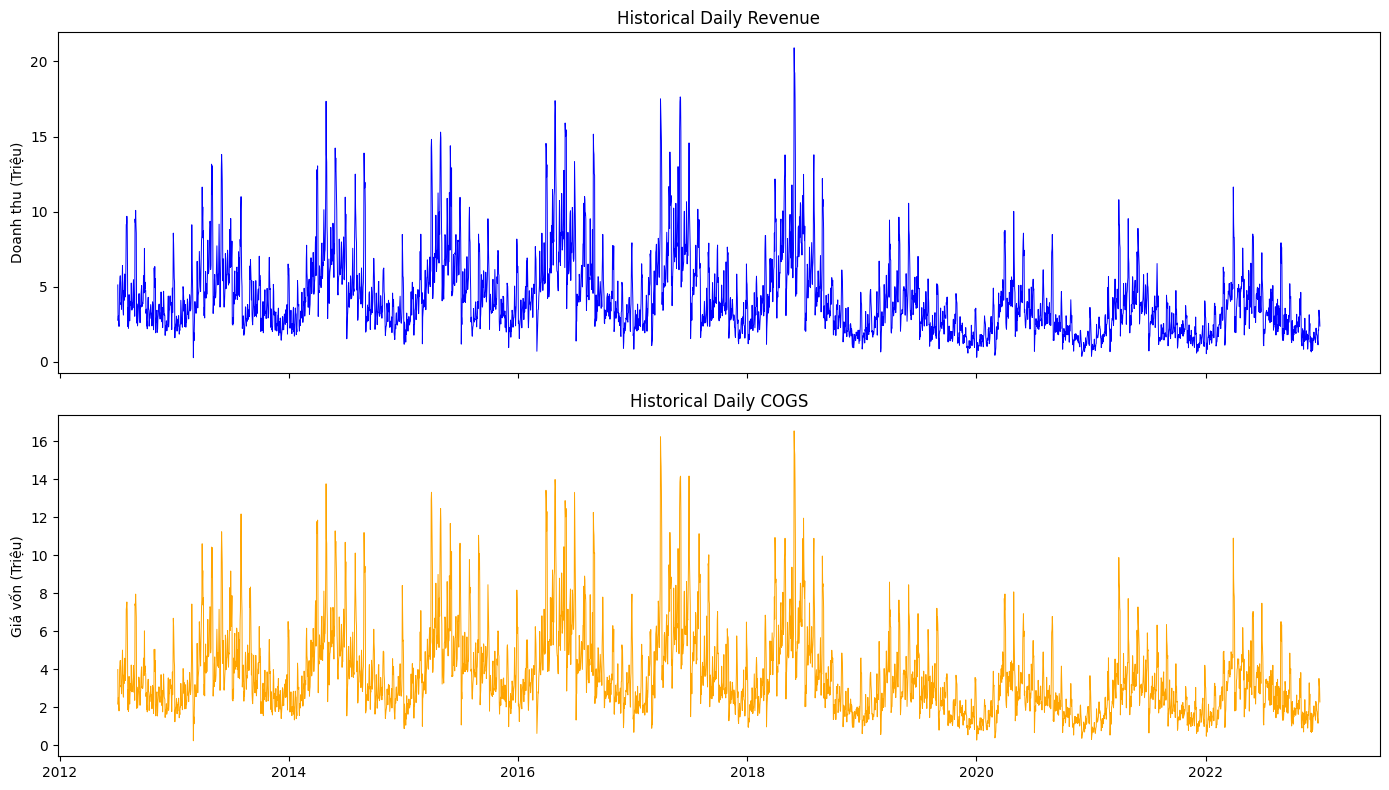

In [5]:
# Biểu đồ Doanh thu (quy ra Triệu VNĐ)
sales['Revenue_Million'] = sales['Revenue'] / 1e6
sales['COGS_Million'] = sales['COGS'] / 1e6

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(sales['Date'], sales['Revenue_Million'], lw=0.7, color='blue')
axes[0].set_title('Historical Daily Revenue')
axes[0].set_ylabel('Doanh thu (Triệu)')

axes[1].plot(sales['Date'], sales['COGS_Million'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS')
axes[1].set_ylabel('Giá vốn (Triệu)')

plt.tight_layout()
plt.show()

## 4. Kiểm chứng nhanh PA3 (Bảng 4.1)
Baseline seasonal-naive và SARIMA trên chuỗi ngày.

In [7]:
merged_pa3 = pd.merge(order_items, orders[['order_id', 'order_date', 'order_status']], on='order_id')
merged_pa3 = merged_pa3[merged_pa3['order_status'] != 'cancelled']
merged_pa3['revenue'] = merged_pa3['quantity'] * merged_pa3['unit_price'] - merged_pa3['discount_amount'].fillna(0)

daily_revenue = merged_pa3.groupby('order_date')['revenue'].sum().reset_index()
daily_revenue['order_date'] = pd.to_datetime(daily_revenue['order_date'])
daily_revenue = daily_revenue.sort_values('order_date').set_index('order_date')

train = daily_revenue.loc[:'2020-12-31']
val = daily_revenue.loc['2021-01-01':'2021-12-31']

def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

y_combined = pd.concat([train['revenue'], val['revenue']])

t0 = time.time()
pred_snaive_364 = y_combined.shift(364).loc['2021-01-01':'2021-12-31']
time_snaive = time.time() - t0
wmape_snaive = wmape(val['revenue'], pred_snaive_364)
mae_snaive = mae(val['revenue'], pred_snaive_364)

t0 = time.time()
sarima_preds = []
cutoff = pd.to_datetime('2020-12-31')
end_date = pd.to_datetime('2021-12-31')

while cutoff < end_date:
    train_chunk = daily_revenue.loc[:cutoff]['revenue']
    model = SARIMAX(train_chunk, order=(1,1,1), seasonal_order=(0,1,1,7))
    res = model.fit(disp=False)
    
    pred_start = cutoff + pd.Timedelta(days=1)
    pred_end = min(cutoff + pd.Timedelta(days=28), end_date)
    
    pred = res.predict(start=pred_start, end=pred_end)
    sarima_preds.append(pred)
    
    cutoff = cutoff + pd.Timedelta(days=28)

sarima_preds_series = pd.concat(sarima_preds)
time_sarima = time.time() - t0
wmape_sarima = wmape(val['revenue'], sarima_preds_series)
mae_sarima = mae(val['revenue'], sarima_preds_series)

results = pd.DataFrame({
    'Model': ['Seasonal-Naive (364 days)', 'SARIMA (28-day batches)'],
    'WMAPE': [f"{wmape_snaive*100:.2f}%", f"{wmape_sarima*100:.2f}%"],
    'MAE (Triệu VNĐ)': [f"{mae_snaive/1e6:.2f}", f"{mae_sarima/1e6:.2f}"],
    'Thời gian chạy (s)': [f"{time_snaive:.2f}", f"{time_sarima:.2f}"]
})
display(results)

print("\nKẾT LUẬN: SARIMA không vượt được seasonal-naive, và mất rất nhiều thời gian chạy.")

,Model,WMAPE,MAE (Triệu VNĐ),Thời gian chạy (s)
0,Seasonal-Naive (364 days),27.82%,0.69,0.00
1,SARIMA (28-day batches),35.97%,0.89,46.08



KẾT LUẬN: SARIMA không vượt được seasonal-naive, và mất rất nhiều thời gian chạy.
